# 實驗 30：各時間點獨立預測力分析

**延續**：Nb14 健檢次數實驗的深化分析

**研究問題**：T1、T2、T3、T4 各自對三項疾病的獨立預測力為何？哪個時間點的預測貢獻最大？

**背景**：
- Nb14 cell 23 已發現高血壓 T1 alone AUC = 0.786 遠高於 T2-T4（0.627-0.666）
- Meeting 23 教授回饋：需要量化各時間點的獨立預測力，並擴展至三項疾病

**實驗設計**：

| 配置 | 特徵集 | 特徵數 | 說明 |
|------|--------|--------|------|
| T1 alone | sex, Age + T1 指標 | 10 | 最早時間點（距 T5 約 8 年） |
| T2 alone | sex, Age + T2 指標 | 10 | 第二次健檢 |
| T3 alone | sex, Age + T3 指標 | 10 | 第三次健檢 |
| T4 alone | sex, Age + T4 指標 | 10 | 最近時間點（距 T5 約 2 年） |

**樣本**：5 次以上健檢者（n=2,526），全部預測 T5

**交叉驗證**：StratifiedKFold 5-fold（每人僅一筆，無需 GroupKFold）

**模型**：LR（主要）、RF、XGBoost（輔助比較）

**日期**：2026-03-24

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score
from sklearn.base import clone
import xgboost as xgb
from scipy import stats
import time

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print('套件載入完成')

套件載入完成


## 1. 載入資料與篩選

In [2]:
# 載入 wide format 資料
df = pd.read_csv('../../data/01_primary/SUA/processed/SUA_CVDs_wide_format.csv')
print(f'原始資料：{len(df):,} 人，{df.shape[1]} 個欄位')

# 計算健檢次數
biomarkers = ['FBG', 'TC', 'Cr', 'UA', 'GFR', 'BMI', 'SBP', 'DBP']

def count_checkups(row):
    for t in range(8, 0, -1):
        if f'FBG_T{t}' in row.index and pd.notna(row[f'FBG_T{t}']):
            return t
    return 0

df['num_checkups'] = df.apply(count_checkups, axis=1)

print('\n健檢次數分佈：')
for n, count in df['num_checkups'].value_counts().sort_index().items():
    print(f'  {n} 次：{count:,} 人 ({count/len(df)*100:.1f}%)')

# 篩選 5 次以上
df5 = df[df['num_checkups'] >= 5].copy()
print(f'\n篩選後：{len(df5):,} 人（5 次以上健檢）')

原始資料：6,056 人，107 個欄位

健檢次數分佈：
  3 次：1,754 人 (29.0%)
  4 次：1,776 人 (29.3%)
  5 次：1,935 人 (32.0%)
  6 次：556 人 (9.2%)
  7 次：31 人 (0.5%)
  8 次：4 人 (0.1%)

篩選後：2,526 人（5 次以上健檢）


In [3]:
# 定義特徵集
demographic = ['sex', 'Age']

configs = {}
for t in [1, 2, 3, 4]:
    configs[f'T{t} alone'] = demographic + [f'{b}_T{t}' for b in biomarkers]

target_cols = {
    '高血壓': 'hypertension_T5',
    '高血糖': 'hyperglycemia_T5',
    '高血脂': 'dyslipidemia_T5',
}

print('各配置特徵數：')
for name, feats in configs.items():
    print(f'  {name}: {len(feats)} 個特徵 → {feats}')

# 確認目標變數分佈
print('\nT5 目標變數陽性率：')
for disease, col in target_cols.items():
    y = (df5[col] == 2).astype(int)
    print(f'  {disease}: {y.sum()}/{len(y)} ({y.mean()*100:.1f}%)')

各配置特徵數：
  T1 alone: 10 個特徵 → ['sex', 'Age', 'FBG_T1', 'TC_T1', 'Cr_T1', 'UA_T1', 'GFR_T1', 'BMI_T1', 'SBP_T1', 'DBP_T1']
  T2 alone: 10 個特徵 → ['sex', 'Age', 'FBG_T2', 'TC_T2', 'Cr_T2', 'UA_T2', 'GFR_T2', 'BMI_T2', 'SBP_T2', 'DBP_T2']
  T3 alone: 10 個特徵 → ['sex', 'Age', 'FBG_T3', 'TC_T3', 'Cr_T3', 'UA_T3', 'GFR_T3', 'BMI_T3', 'SBP_T3', 'DBP_T3']
  T4 alone: 10 個特徵 → ['sex', 'Age', 'FBG_T4', 'TC_T4', 'Cr_T4', 'UA_T4', 'GFR_T4', 'BMI_T4', 'SBP_T4', 'DBP_T4']

T5 目標變數陽性率：
  高血壓: 549/2526 (21.7%)
  高血糖: 168/2526 (6.7%)
  高血脂: 312/2526 (12.4%)


## 2. 評估函式

In [4]:
def get_models():
    return {
        'LR': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'RF': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
        'XGB': xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                  random_state=42, eval_metric='logloss', verbosity=0),
    }


def evaluate_cv(df_sub, feature_cols, target_col, model, n_splits=5, random_state=42):
    X = df_sub[feature_cols].copy()
    y = (df_sub[target_col] == 2).astype(int)
    
    # 移除 NaN
    mask = ~(X.isna().any(axis=1) | y.isna())
    X, y = X[mask], y[mask]
    
    if len(y.unique()) < 2:
        return None
    
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_auc, fold_sens, fold_spec, fold_f1 = [], [], [], []
    
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        m = clone(model)
        if isinstance(m, xgb.XGBClassifier):
            m.set_params(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
        
        m.fit(X_train_s, y_train)
        y_prob = m.predict_proba(X_test_s)[:, 1]
        y_pred = m.predict(X_test_s)
        
        fold_auc.append(roc_auc_score(y_test, y_prob))
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        fold_sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fold_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        fold_f1.append(f1_score(y_test, y_pred, zero_division=0))
    
    return {
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'sens_mean': np.mean(fold_sens), 'spec_mean': np.mean(fold_spec),
        'f1_mean': np.mean(fold_f1),
        'auc_folds': fold_auc,
        'n_samples': len(y),
    }

print('評估函式定義完成')

評估函式定義完成


## 3. 執行實驗

In [5]:
start_time = time.time()
results = []

for config_name, feature_cols in configs.items():
    print(f'\n{"=" * 60}')
    print(f'{config_name}（{len(feature_cols)} 個特徵）')
    print(f'{"=" * 60}')
    
    for disease_name, target_col in target_cols.items():
        print(f'\n  --- {disease_name} ---')
        models = get_models()
        
        for model_name, model in models.items():
            print(f'    {model_name}...', end=' ')
            r = evaluate_cv(df5, feature_cols, target_col, model)
            
            if r is None:
                print('SKIP (只有一個類別)')
                continue
            
            results.append({
                '配置': config_name,
                '疾病': disease_name,
                '模型': model_name,
                'AUC': r['auc_mean'],
                'AUC_std': r['auc_std'],
                'Sensitivity': r['sens_mean'],
                'Specificity': r['spec_mean'],
                'F1': r['f1_mean'],
                'auc_folds': r['auc_folds'],
                'n_samples': r['n_samples'],
            })
            print(f'AUC = {r["auc_mean"]:.3f} ± {r["auc_std"]:.3f}  (n={r["n_samples"]})')

elapsed = time.time() - start_time
print(f'\n總執行時間：{elapsed:.1f} 秒')


T1 alone（10 個特徵）

  --- 高血壓 ---
    LR... AUC = 0.786 ± 0.011  (n=2526)
    RF... AUC = 0.777 ± 0.014  (n=2526)
    XGB... AUC = 0.766 ± 0.009  (n=2526)

  --- 高血糖 ---
    LR... AUC = 0.868 ± 0.047  (n=2526)
    RF... AUC = 0.827 ± 0.045  (n=2526)
    XGB... AUC = 0.825 ± 0.043  (n=2526)

  --- 高血脂 ---
    LR... AUC = 0.814 ± 0.030  (n=2526)
    RF... AUC = 0.785 ± 0.038  (n=2526)
    XGB... AUC = 0.780 ± 0.025  (n=2526)

T2 alone（10 個特徵）

  --- 高血壓 ---
    LR... AUC = 0.627 ± 0.025  (n=2526)
    RF... AUC = 0.581 ± 0.023  (n=2526)
    XGB... AUC = 0.578 ± 0.028  (n=2526)

  --- 高血糖 ---
    LR... AUC = 0.903 ± 0.033  (n=2526)
    RF... AUC = 0.878 ± 0.030  (n=2526)
    XGB... AUC = 0.862 ± 0.033  (n=2526)

  --- 高血脂 ---
    LR... AUC = 0.831 ± 0.020  (n=2526)
    RF... AUC = 0.805 ± 0.035  (n=2526)
    XGB... AUC = 0.793 ± 0.042  (n=2526)

T3 alone（10 個特徵）

  --- 高血壓 ---
    LR... AUC = 0.653 ± 0.025  (n=2526)
    RF... AUC = 0.618 ± 0.023  (n=2526)
    XGB... AUC = 0.610 ± 0.031  (n=

## 4. 結果整理

In [6]:
results_df = pd.DataFrame(results)

# === LR 主要結果表 ===
print('=' * 80)
print('LR 各時間點獨立預測力（AUC）')
print('=' * 80)

lr_df = results_df[results_df['模型'] == 'LR'].copy()
pivot = lr_df.pivot(index='疾病', columns='配置', values='AUC').round(3)
pivot = pivot[list(configs.keys())]  # T1, T2, T3, T4 順序
print(pivot)

# 各疾病的最強時間點
print('\n--- 各疾病最強 / 最弱時間點 ---')
for disease in target_cols.keys():
    d = lr_df[lr_df['疾病'] == disease].set_index('配置')['AUC']
    best = d.idxmax()
    worst = d.idxmin()
    spread = d.max() - d.min()
    print(f'  {disease}: 最強={best} ({d[best]:.3f}), 最弱={worst} ({d[worst]:.3f}), 差距={spread:.3f}')

LR 各時間點獨立預測力（AUC）
配置   T1 alone  T2 alone  T3 alone  T4 alone
疾病                                         
高血壓     0.786     0.627     0.653     0.666
高血糖     0.868     0.903     0.905     0.931
高血脂     0.814     0.831     0.818     0.867

--- 各疾病最強 / 最弱時間點 ---
  高血壓: 最強=T1 alone (0.786), 最弱=T2 alone (0.627), 差距=0.159
  高血糖: 最強=T4 alone (0.931), 最弱=T1 alone (0.868), 差距=0.063
  高血脂: 最強=T4 alone (0.867), 最弱=T1 alone (0.814), 差距=0.053


In [7]:
# === 三模型完整結果表 ===
print('=' * 90)
print('三模型 × 四時間點 完整結果')
print('=' * 90)

config_order = list(configs.keys())
model_order = ['LR', 'RF', 'XGB']

for disease in target_cols.keys():
    print(f'\n--- {disease} ---')
    print(f'{"模型":>5}  {"T1 alone":>18}  {"T2 alone":>18}  {"T3 alone":>18}  {"T4 alone":>18}')
    print('-' * 85)
    
    for model_name in model_order:
        vals = []
        for config_name in config_order:
            r = results_df[(results_df['配置'] == config_name) & 
                          (results_df['疾病'] == disease) & 
                          (results_df['模型'] == model_name)]
            if len(r) > 0:
                vals.append(f'{r["AUC"].values[0]:.3f} ± {r["AUC_std"].values[0]:.3f}')
            else:
                vals.append('N/A')
        print(f'{model_name:>5}  {vals[0]:>18}  {vals[1]:>18}  {vals[2]:>18}  {vals[3]:>18}')

三模型 × 四時間點 完整結果

--- 高血壓 ---
   模型            T1 alone            T2 alone            T3 alone            T4 alone
-------------------------------------------------------------------------------------
   LR       0.786 ± 0.011       0.627 ± 0.025       0.653 ± 0.025       0.666 ± 0.019
   RF       0.777 ± 0.014       0.581 ± 0.023       0.618 ± 0.023       0.657 ± 0.028
  XGB       0.766 ± 0.009       0.578 ± 0.028       0.610 ± 0.031       0.639 ± 0.022

--- 高血糖 ---
   模型            T1 alone            T2 alone            T3 alone            T4 alone
-------------------------------------------------------------------------------------
   LR       0.868 ± 0.047       0.903 ± 0.033       0.905 ± 0.030       0.931 ± 0.018
   RF       0.827 ± 0.045       0.878 ± 0.030       0.876 ± 0.032       0.915 ± 0.026
  XGB       0.825 ± 0.043       0.862 ± 0.033       0.876 ± 0.033       0.900 ± 0.036

--- 高血脂 ---
   模型            T1 alone            T2 alone            T3 alone            T4 alone

## 5. 與 Nb14 健檢次數實驗交叉比較

Nb14 結果回顧：
- 1次(T4→T5): HTN 0.666, HG 0.931, DL 0.867
- 2次(T3,T4→T5): HTN 0.679, HG 0.940, DL 0.879
- 3次(T2~T4→T5): HTN 0.676, HG 0.942, DL 0.883
- 4次(T1~T4→T5): HTN 0.835, HG 0.945, DL 0.882

本實驗補充：各時間點「單獨」的預測力，解釋為何加入 T1 後 HTN 跳升 +16.9%

In [8]:
# 與 Nb14 結果交叉比較
nb14_results = {
    '高血壓': {'1次(T4)': 0.666, '2次(T3,T4)': 0.679, '3次(T2~T4)': 0.676, '4次(T1~T4)': 0.835},
    '高血糖': {'1次(T4)': 0.931, '2次(T3,T4)': 0.940, '3次(T2~T4)': 0.942, '4次(T1~T4)': 0.945},
    '高血脂': {'1次(T4)': 0.867, '2次(T3,T4)': 0.879, '3次(T2~T4)': 0.883, '4次(T1~T4)': 0.882},
}

print('=' * 90)
print('Nb14 累積健檢次數 vs Nb30 各時間點獨立預測力（LR）')
print('=' * 90)

for disease in target_cols.keys():
    print(f'\n--- {disease} ---')
    print('  [Nb14 累積]')
    for name, auc in nb14_results[disease].items():
        print(f'    {name}: AUC = {auc:.3f}')
    
    print('  [Nb30 單獨]')
    for config_name in config_order:
        r = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == config_name)]
        if len(r) > 0:
            print(f'    {config_name}: AUC = {r["AUC"].values[0]:.3f}')
    
    # 分析
    t1_auc = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == 'T1 alone')]['AUC'].values[0]
    t4_auc = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == 'T4 alone')]['AUC'].values[0]
    nb14_4x = nb14_results[disease]['4次(T1~T4)']
    print(f'  → T1 alone ({t1_auc:.3f}) vs T4 alone ({t4_auc:.3f}): diff = {t1_auc - t4_auc:+.3f}')
    print(f'  → T1 alone ({t1_auc:.3f}) vs 4次累積 ({nb14_4x:.3f}): 4次累積額外 {nb14_4x - t1_auc:+.3f}')

Nb14 累積健檢次數 vs Nb30 各時間點獨立預測力（LR）

--- 高血壓 ---
  [Nb14 累積]
    1次(T4): AUC = 0.666
    2次(T3,T4): AUC = 0.679
    3次(T2~T4): AUC = 0.676
    4次(T1~T4): AUC = 0.835
  [Nb30 單獨]
    T1 alone: AUC = 0.786
    T2 alone: AUC = 0.627
    T3 alone: AUC = 0.653
    T4 alone: AUC = 0.666
  → T1 alone (0.786) vs T4 alone (0.666): diff = +0.120
  → T1 alone (0.786) vs 4次累積 (0.835): 4次累積額外 +0.049

--- 高血糖 ---
  [Nb14 累積]
    1次(T4): AUC = 0.931
    2次(T3,T4): AUC = 0.940
    3次(T2~T4): AUC = 0.942
    4次(T1~T4): AUC = 0.945
  [Nb30 單獨]
    T1 alone: AUC = 0.868
    T2 alone: AUC = 0.903
    T3 alone: AUC = 0.905
    T4 alone: AUC = 0.931
  → T1 alone (0.868) vs T4 alone (0.931): diff = -0.063
  → T1 alone (0.868) vs 4次累積 (0.945): 4次累積額外 +0.077

--- 高血脂 ---
  [Nb14 累積]
    1次(T4): AUC = 0.867
    2次(T3,T4): AUC = 0.879
    3次(T2~T4): AUC = 0.883
    4次(T1~T4): AUC = 0.882
  [Nb30 單獨]
    T1 alone: AUC = 0.814
    T2 alone: AUC = 0.831
    T3 alone: AUC = 0.818
    T4 alone: AUC = 0.867
  → T1 alone

## 6. 視覺化

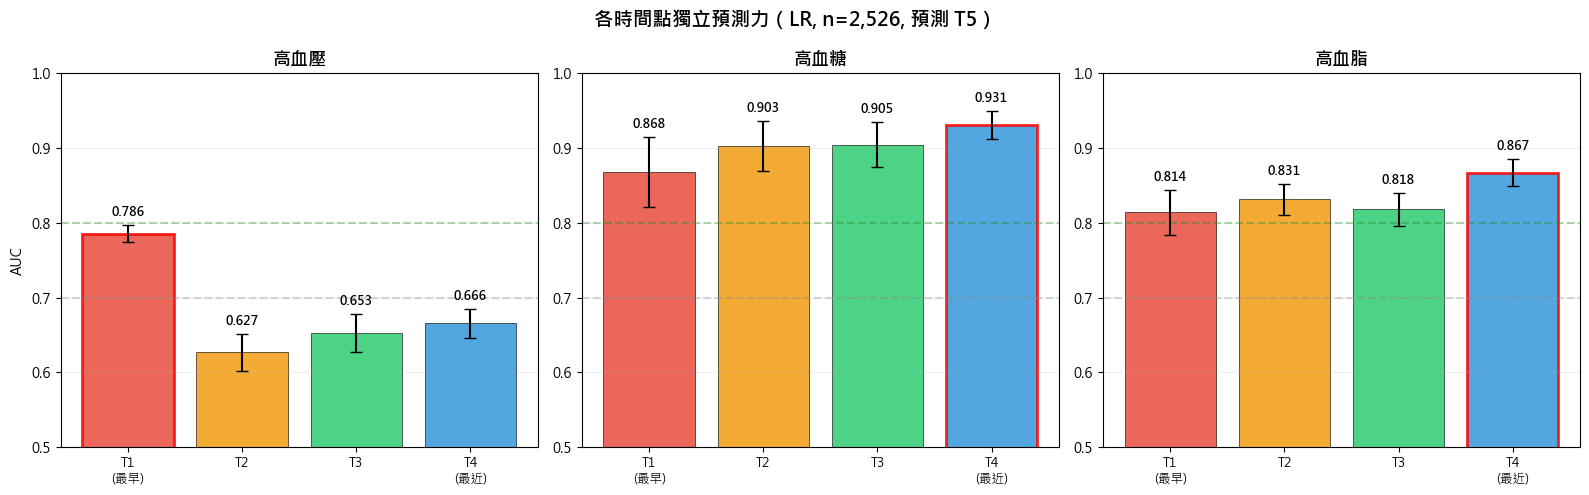

已儲存：results/per_timepoint_prediction_lr.png


In [9]:
# LR 各時間點獨立預測力（主圖）
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

diseases = list(target_cols.keys())
timepoints = ['T1 alone', 'T2 alone', 'T3 alone', 'T4 alone']
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for idx, disease in enumerate(diseases):
    ax = axes[idx]
    aucs, stds = [], []
    for tp in timepoints:
        r = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == tp)]
        aucs.append(r['AUC'].values[0])
        stds.append(r['AUC_std'].values[0])
    
    x = np.arange(4)
    bars = ax.bar(x, aucs, yerr=stds, capsize=4, color=colors, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    
    for i, (auc, std) in enumerate(zip(aucs, stds)):
        ax.text(i, auc + std + 0.008, f'{auc:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    
    # 標出最強時間點
    best_idx = np.argmax(aucs)
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2)
    
    ax.set_title(disease, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['T1\n(最早)', 'T2', 'T3', 'T4\n(最近)'], fontsize=9)
    ax.set_ylabel('AUC' if idx == 0 else '')
    ax.set_ylim(0.5, 1.0)
    ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.3)
    ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('各時間點獨立預測力（LR, n=2,526, 預測 T5）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../results/per_timepoint_prediction_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print('已儲存：results/per_timepoint_prediction_lr.png')

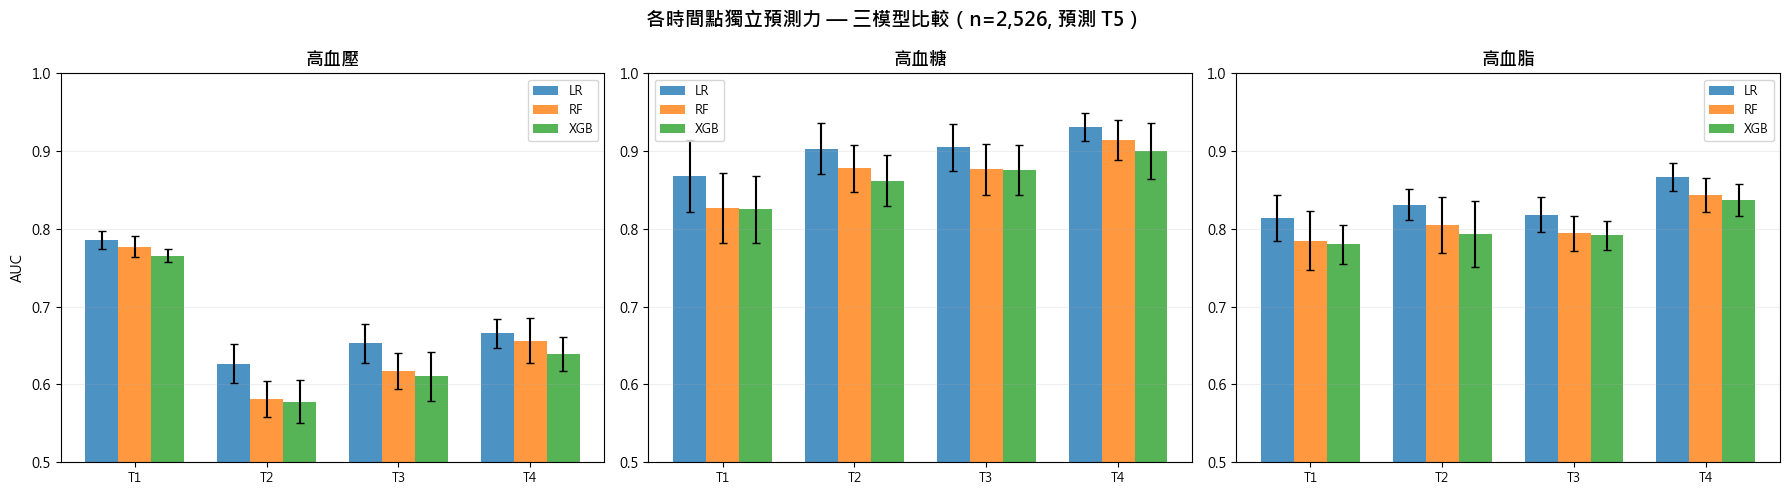

已儲存：results/per_timepoint_prediction_3models.png


In [10]:
# 三模型比較圖
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, disease in enumerate(diseases):
    ax = axes[idx]
    x = np.arange(4)
    width = 0.25
    
    for j, model_name in enumerate(model_order):
        aucs, stds = [], []
        for tp in timepoints:
            r = results_df[(results_df['配置'] == tp) &
                          (results_df['疾病'] == disease) &
                          (results_df['模型'] == model_name)]
            aucs.append(r['AUC'].values[0])
            stds.append(r['AUC_std'].values[0])
        ax.bar(x + j * width, aucs, width, yerr=stds, label=model_name, capsize=3, alpha=0.8)
    
    ax.set_title(disease, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(['T1', 'T2', 'T3', 'T4'], fontsize=9)
    ax.set_ylabel('AUC' if idx == 0 else '')
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('各時間點獨立預測力 — 三模型比較（n=2,526, 預測 T5）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../results/per_timepoint_prediction_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print('已儲存：results/per_timepoint_prediction_3models.png')

## 7. 統計檢定

In [11]:
# Paired t-test: 各時間點兩兩比較（LR only）
print('=' * 80)
print('統計檢定：各時間點兩兩比較（LR, Paired t-test on 5-fold AUC）')
print('=' * 80)

pairs = [('T1 alone', 'T4 alone'), ('T1 alone', 'T2 alone'),
         ('T3 alone', 'T4 alone'), ('T1 alone', 'T3 alone')]

for disease in target_cols.keys():
    print(f'\n--- {disease} ---')
    print(f'{"比較":>20}  {"AUC_A":>8}  {"AUC_B":>8}  {"diff":>8}  {"t-stat":>8}  {"p-value":>8}  {"sig":>4}')
    print('-' * 75)
    
    for tp_a, tp_b in pairs:
        r_a = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == tp_a)]
        r_b = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == tp_b)]
        
        folds_a = r_a['auc_folds'].values[0]
        folds_b = r_b['auc_folds'].values[0]
        t_stat, p_val = stats.ttest_rel(folds_a, folds_b)
        sig = '**' if p_val < 0.01 else ('*' if p_val < 0.05 else '')
        diff = r_a['AUC'].values[0] - r_b['AUC'].values[0]
        
        print(f'{tp_a + " vs " + tp_b:>20}  {r_a["AUC"].values[0]:>8.3f}  {r_b["AUC"].values[0]:>8.3f}  {diff:>+8.3f}  {t_stat:>8.3f}  {p_val:>8.4f}  {sig:>4}')

統計檢定：各時間點兩兩比較（LR, Paired t-test on 5-fold AUC）

--- 高血壓 ---
                  比較     AUC_A     AUC_B      diff    t-stat   p-value   sig
---------------------------------------------------------------------------
T1 alone vs T4 alone     0.786     0.666    +0.120    17.499    0.0001    **
T1 alone vs T2 alone     0.786     0.627    +0.159     9.656    0.0006    **
T3 alone vs T4 alone     0.653     0.666    -0.013    -1.490    0.2105      
T1 alone vs T3 alone     0.786     0.653    +0.133    10.138    0.0005    **

--- 高血糖 ---
                  比較     AUC_A     AUC_B      diff    t-stat   p-value   sig
---------------------------------------------------------------------------
T1 alone vs T4 alone     0.868     0.931    -0.063    -2.891    0.0445     *
T1 alone vs T2 alone     0.868     0.903    -0.035    -1.476    0.2140      
T3 alone vs T4 alone     0.905     0.931    -0.026    -2.425    0.0724      
T1 alone vs T3 alone     0.868     0.905    -0.037    -1.343    0.2504      

--- 

## 8. 論文用表格（Markdown）

In [12]:
# 論文表格：LR 主要結果
print('### 表 6-X 各時間點獨立預測力（LR, n=2,526）')
print()
print('| 疾病 | T1 alone | T2 alone | T3 alone | T4 alone | 最強 | 差距 |')
print('|------|----------|----------|----------|----------|------|------|')

for disease in target_cols.keys():
    vals = {}
    for tp in timepoints:
        r = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == tp)]
        vals[tp] = (r['AUC'].values[0], r['AUC_std'].values[0])
    
    aucs = {tp: v[0] for tp, v in vals.items()}
    best_tp = max(aucs, key=aucs.get)
    spread = max(aucs.values()) - min(aucs.values())
    
    row = f'| {disease}'
    for tp in timepoints:
        auc, std = vals[tp]
        bold = '**' if tp == best_tp else ''
        row += f' | {bold}{auc:.3f}{bold} ± {std:.3f}'
    row += f' | {best_tp.replace(" alone", "")} | {spread:.3f} |'
    print(row)

### 表 6-X 各時間點獨立預測力（LR, n=2,526）

| 疾病 | T1 alone | T2 alone | T3 alone | T4 alone | 最強 | 差距 |
|------|----------|----------|----------|----------|------|------|
| 高血壓 | **0.786** ± 0.011 | 0.627 ± 0.025 | 0.653 ± 0.025 | 0.666 ± 0.019 | T1 | 0.159 |
| 高血糖 | 0.868 ± 0.047 | 0.903 ± 0.033 | 0.905 ± 0.030 | **0.931** ± 0.018 | T4 | 0.063 |
| 高血脂 | 0.814 ± 0.030 | 0.831 ± 0.020 | 0.818 ± 0.022 | **0.867** ± 0.018 | T4 | 0.053 |


In [13]:
# 論文表格：三模型完整結果
print('### 表 6-X 各時間點獨立預測力（三模型, n=2,526）')
print()
print('| 疾病 | 模型 | T1 alone | T2 alone | T3 alone | T4 alone |')
print('|------|------|----------|----------|----------|----------|')

for disease in target_cols.keys():
    for model_name in model_order:
        row = f'| {disease} | {model_name}'
        for tp in timepoints:
            r = results_df[(results_df['配置'] == tp) &
                          (results_df['疾病'] == disease) &
                          (results_df['模型'] == model_name)]
            if len(r) > 0:
                row += f' | {r["AUC"].values[0]:.3f} ± {r["AUC_std"].values[0]:.3f}'
        row += ' |'
        print(row)

### 表 6-X 各時間點獨立預測力（三模型, n=2,526）

| 疾病 | 模型 | T1 alone | T2 alone | T3 alone | T4 alone |
|------|------|----------|----------|----------|----------|
| 高血壓 | LR | 0.786 ± 0.011 | 0.627 ± 0.025 | 0.653 ± 0.025 | 0.666 ± 0.019 |
| 高血壓 | RF | 0.777 ± 0.014 | 0.581 ± 0.023 | 0.618 ± 0.023 | 0.657 ± 0.028 |
| 高血壓 | XGB | 0.766 ± 0.009 | 0.578 ± 0.028 | 0.610 ± 0.031 | 0.639 ± 0.022 |
| 高血糖 | LR | 0.868 ± 0.047 | 0.903 ± 0.033 | 0.905 ± 0.030 | 0.931 ± 0.018 |
| 高血糖 | RF | 0.827 ± 0.045 | 0.878 ± 0.030 | 0.876 ± 0.032 | 0.915 ± 0.026 |
| 高血糖 | XGB | 0.825 ± 0.043 | 0.862 ± 0.033 | 0.876 ± 0.033 | 0.900 ± 0.036 |
| 高血脂 | LR | 0.814 ± 0.030 | 0.831 ± 0.020 | 0.818 ± 0.022 | 0.867 ± 0.018 |
| 高血脂 | RF | 0.785 ± 0.038 | 0.805 ± 0.035 | 0.794 ± 0.023 | 0.844 ± 0.022 |
| 高血脂 | XGB | 0.780 ± 0.025 | 0.793 ± 0.042 | 0.792 ± 0.019 | 0.837 ± 0.021 |


## 9. 結論摘要

In [14]:
print('=' * 80)
print('實驗 30 結論摘要')
print('=' * 80)

print('\n1. 各時間點獨立預測力（LR）：')
for disease in target_cols.keys():
    aucs = {}
    for tp in timepoints:
        r = lr_df[(lr_df['疾病'] == disease) & (lr_df['配置'] == tp)]
        aucs[tp] = r['AUC'].values[0]
    best = max(aucs, key=aucs.get)
    print(f'  {disease}: T1={aucs["T1 alone"]:.3f}, T2={aucs["T2 alone"]:.3f}, '
          f'T3={aucs["T3 alone"]:.3f}, T4={aucs["T4 alone"]:.3f} → 最強={best}')

print('\n2. 與 Nb14 健檢次數實驗的連結：')
print('  - Nb14 發現加入 T1 後高血壓 AUC 從 0.676 跳升至 0.835（+0.159）')
print('  - 本實驗量化了 T1 alone 的獨立預測力，解釋此跳升的來源')
print('  - [待填入：三項疾病的時間點重要性模式差異]')

print('\n3. 臨床意涵：')
print('  - [待填入：根據結果分析]')

# 儲存結果
save_df = results_df.drop(columns=['auc_folds'])
save_df.to_csv('../../results/per_timepoint_prediction_results.csv', index=False)
print('\n已儲存：results/per_timepoint_prediction_results.csv')

實驗 30 結論摘要

1. 各時間點獨立預測力（LR）：
  高血壓: T1=0.786, T2=0.627, T3=0.653, T4=0.666 → 最強=T1 alone
  高血糖: T1=0.868, T2=0.903, T3=0.905, T4=0.931 → 最強=T4 alone
  高血脂: T1=0.814, T2=0.831, T3=0.818, T4=0.867 → 最強=T4 alone

2. 與 Nb14 健檢次數實驗的連結：
  - Nb14 發現加入 T1 後高血壓 AUC 從 0.676 跳升至 0.835（+0.159）
  - 本實驗量化了 T1 alone 的獨立預測力，解釋此跳升的來源
  - [待填入：三項疾病的時間點重要性模式差異]

3. 臨床意涵：
  - [待填入：根據結果分析]

已儲存：results/per_timepoint_prediction_results.csv
